<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/CNN_Implementation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# Core Python Libraries
# =========================
import os
import glob
import time
import copy
import random
import warnings

# =========================
# Numerical / Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Image Processing / Display
# =========================
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Scikit-learn Utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# PyTorch Core
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# =========================
# PyTorch Dataset / DataLoader
# =========================
from torch.utils.data import Dataset, DataLoader, TensorDataset

# =========================
# Torchvision
# =========================
from torchvision import models, transforms

# =========================
# Progress Bar
# =========================
from tqdm import tqdm

# =========================
# Optional: Ignore Warnings
# =========================
warnings.filterwarnings("ignore")

# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# For more reproducible behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Device Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Count: 1


In [ ]:
# =========================
# Helper Functions
# =========================

def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)


def denormalize_image(img_tensor, mean, std):
    """
    Convert normalized tensor image back to displayable numpy image.
    img_tensor shape: (C, H, W)
    """
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img


def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total_acc += (preds == labels).sum().item() / len(labels)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    avg_acc = total_acc / len(data_loader)

    return avg_loss, avg_acc, all_labels, all_preds


def plot_confusion_matrix(all_labels, all_preds, class_names=("Cat", "Dog"), title="Confusion Matrix"):
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


def show_predictions_from_loader(model, loader, device, class_names=("Cat", "Dog"), n=6,
                                 mean=(0.485, 0.456, 0.406),
                                 std=(0.229, 0.224, 0.225)):
    model.eval()

    images, labels = next(iter(loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 6))

    for i in range(min(n, len(images))):
        img = denormalize_image(images[i], mean, std)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i].item()]} | Pred: {class_names[preds[i].item()]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_wrong_predictions_from_loader(model, loader, device, class_names=("Cat", "Dog"), n=6,
                                       mean=(0.485, 0.456, 0.406),
                                       std=(0.229, 0.224, 0.225)):
    model.eval()

    wrong_images = []
    wrong_labels = []
    wrong_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels_device[i]:
                    wrong_images.append(images[i].cpu())
                    wrong_labels.append(labels[i].item())
                    wrong_preds.append(preds[i].cpu().item())

                if len(wrong_images) == n:
                    break

            if len(wrong_images) == n:
                break

    if len(wrong_images) == 0:
        print("No wrong predictions found in the scanned batches.")
        return

    plt.figure(figsize=(12, 6))

    for i in range(len(wrong_images)):
        img = denormalize_image(wrong_images[i], mean, std)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[wrong_labels[i]]} | Pred: {class_names[wrong_preds[i]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# 🔄 Why Add Data Augmentation Now?

Earlier, our custom CNN learned from fixed images only.

---

### 🚨 Problem

Real-world images can vary due to:

- Rotation  
- Flip  
- Lighting  
- Small viewpoint changes  

---

### 🎯 Solution

We artificially create image variations during training.

This is called:

$$
\text{Data Augmentation}
$$

---

### 🧠 Why It Helps

$$
\text{More Variation} \Rightarrow \text{Better Generalization}
$$

---

### 🔥 Important Note

- Training data → augmentation applied  
- Validation / Test data → no augmentation  

---

👉 Now the model sees a richer version of the same dataset

In [ ]:
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import copy

# 🧹 Transform Pipelines for ResNet18

For pretrained ResNet18, inputs are typically prepared as:

- Resize to fixed size
- Convert to tensor
- Normalize using ImageNet statistics

---

### 🎯 Why special normalization?

Because ResNet18 was pretrained on ImageNet.

So we should preprocess input similarly.

---

### ImageNet Normalization

$$
x' = \frac{x - \mu}{\sigma}
$$

Where:

$$
\mu = [0.485, 0.456, 0.406]
$$

$$
\sigma = [0.229, 0.224, 0.225]
$$

---

👉 Training transform will include augmentation  
👉 Validation/Test transform will stay clean

In [ ]:
IMG_SIZE_RESNET = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 🧩 Why Do We Need a Custom Dataset Here?

Earlier, we saved preprocessed tensors as `.pt`.

But augmentation must happen:

- dynamically
- differently each time an image is loaded

---

### 🎯 Therefore

We now load images directly from file paths and apply transforms on-the-fly.

---

### Key Benefit

- Efficient augmentation
- Flexible pipeline
- Standard transfer learning workflow

In [ ]:
class CatsDogsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "filepath"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Set dataset path (UPDATE THIS PATH)
dataset_path = "CNN_Demo_Project_1/Training Images"  # e.g., "data/train"

# Get all image file paths
image_paths = glob.glob(os.path.join(dataset_path, "*.jpg"))

print("Total images found:", len(image_paths))
print("Sample paths:", image_paths[:5])

Total images found: 25000
Sample paths: ['CNN_Demo_Project_1/Training Images\\cat.0.jpg', 'CNN_Demo_Project_1/Training Images\\cat.1.jpg', 'CNN_Demo_Project_1/Training Images\\cat.10.jpg', 'CNN_Demo_Project_1/Training Images\\cat.100.jpg', 'CNN_Demo_Project_1/Training Images\\cat.1000.jpg']


In [ ]:
data = []

for path in image_paths:
    filename = os.path.basename(path)
    label_text = filename.split(".")[0]

    label = 0 if label_text == "cat" else 1

    data.append([path, label_text, label])

# Create DataFrame
df = pd.DataFrame(data, columns=["filepath", "label_text", "label"])

print(df.head())
print("\nClass distribution:\n", df["label_text"].value_counts())

                                          filepath label_text  label
0     CNN_Demo_Project_1/Training Images\cat.0.jpg        cat      0
1     CNN_Demo_Project_1/Training Images\cat.1.jpg        cat      0
2    CNN_Demo_Project_1/Training Images\cat.10.jpg        cat      0
3   CNN_Demo_Project_1/Training Images\cat.100.jpg        cat      0
4  CNN_Demo_Project_1/Training Images\cat.1000.jpg        cat      0

Class distribution:
 label_text
cat    12500
dog    12500
Name: count, dtype: int64


In [ ]:
# Separate cat and dog images
cat_df = df[df["label_text"] == "cat"]
dog_df = df[df["label_text"] == "dog"]

print("Total Cats:", len(cat_df))
print("Total Dogs:", len(dog_df))

Total Cats: 12500
Total Dogs: 12500


In [ ]:
# Define sample size per class
sample_size = 6000  # you can change to 4000 or 5000 if needed

cat_sample = cat_df.sample(n=sample_size, random_state=42)
dog_sample = dog_df.sample(n=sample_size, random_state=42)

# Combine
df_sampled = pd.concat([cat_sample, dog_sample]).reset_index(drop=True)

# Shuffle
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sampled dataset size:", len(df_sampled))
print(df_sampled["label_text"].value_counts())

Sampled dataset size: 12000
label_text
cat    6000
dog    6000
Name: count, dtype: int64


In [ ]:
# First split: Train vs Temp (val + test)
train_df, temp_df = train_test_split(
    df_sampled,
    test_size=0.3,
    stratify=df_sampled["label"],
    random_state=42
)

# Second split: Validation vs Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8400
Validation size: 1800
Test size: 1800


In [ ]:
train_dataset_resnet = CatsDogsDataset(train_df, transform=train_transform)
val_dataset_resnet = CatsDogsDataset(val_df, transform=val_test_transform)
test_dataset_resnet = CatsDogsDataset(test_df, transform=val_test_transform)

batch_size_resnet = 32

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size_resnet, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size_resnet, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size_resnet, shuffle=False)

print("Train batches:", len(train_loader_resnet))
print("Validation batches:", len(val_loader_resnet))
print("Test batches:", len(test_loader_resnet))

Train batches: 263
Validation batches: 57
Test batches: 57


# 👁️ Visualizing Augmented Samples

A single training image can appear in multiple forms:

- flipped
- slightly rotated
- transformed

---

### 🎯 Key Insight

The label remains same, but appearance changes.

---

👉 This helps model become robust to real-world variation

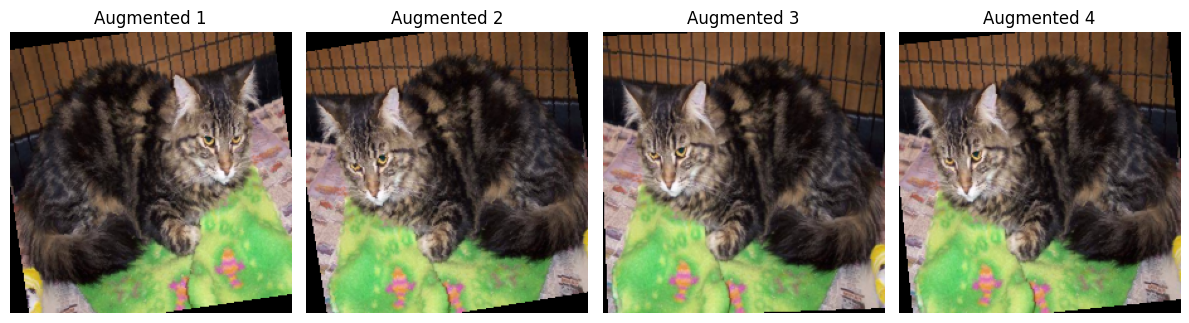

In [ ]:
sample_path = train_df.iloc[0]["filepath"]
sample_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(12, 4))
for i in range(4):
    aug_img = train_transform(sample_image)

    # de-normalize for display
    img_np = aug_img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    plt.subplot(1, 4, i + 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()

# 🧠 Loading Pretrained ResNet18

We now use a model that has already learned from ImageNet.

---

### 🎯 Strategy

- Reuse learned visual features
- Replace final classification layer
- Adapt model for 2 classes

---

### Output change

Original ResNet18 final layer:

- many ImageNet classes

New final layer:

$$
\text{Output dimension} = 2
$$

---

👉 Let’s load and modify the model

In [ ]:
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet18_model.fc.in_features
resnet18_model.fc = nn.Linear(num_features, 2)

resnet18_model = resnet18_model.to(device)

print(resnet18_model.fc)

Linear(in_features=512, out_features=2, bias=True)


# 🧊 Feature Extraction Mode: Freeze Backbone

In feature extraction mode:

- pretrained convolutional layers remain fixed
- only final classifier is trained

---

### Mathematical View

$$
\theta_{\text{backbone}} = \text{fixed}
$$

$$
\theta_{\text{fc}} = \text{trainable}
$$

---

### 🎯 Why Do This?

- Faster training
- Fewer trainable parameters
- Lower overfitting risk

---

👉 Let’s freeze all layers except final FC

In [ ]:
for param in resnet18_model.parameters():
    param.requires_grad = False

for param in resnet18_model.fc.parameters():
    param.requires_grad = True

total_params_resnet = sum(p.numel() for p in resnet18_model.parameters())
trainable_params_resnet = sum(p.numel() for p in resnet18_model.parameters() if p.requires_grad)

print("Total parameters:", total_params_resnet)
print("Trainable parameters:", trainable_params_resnet)

Total parameters: 11177538
Trainable parameters: 1026


# 🎯 Baseline Training Setup for ResNet18

We begin with a simple transfer learning setup:

- CrossEntropyLoss
- Adam optimizer
- train only final FC layer

---

### 🎯 Important

This is our baseline transfer learning experiment.

In [ ]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet18_model.fc.parameters(),
    lr=0.001
)

# 🔁 Training Function for ResNet18

To keep the notebook clean, we define reusable functions for:

- training
- validation
- metric tracking

---

👉 This makes it easy to compare multiple configurations later

In [ ]:
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

def train_model_basic(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0.0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

        train_loss = running_loss / len(train_loader)
        train_acc = running_acc / len(train_loader)

        model.eval()
        val_running_loss = 0.0
        val_running_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                val_running_acc += calculate_accuracy(outputs, labels)

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_running_acc / len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
num_epochs_resnet = 5

resnet18_model, history_resnet_fc = train_model_basic(
    model=resnet18_model,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    device=device,
    num_epochs=num_epochs_resnet
)

100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [03:44<00:00,  1.17it/s]


Epoch [1/5] Train Loss: 0.1804, Train Acc: 0.9307, Val Loss: 0.0891, Val Acc: 0.9731


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:50<00:00,  2.37it/s]


Epoch [2/5] Train Loss: 0.1114, Train Acc: 0.9575, Val Loss: 0.0627, Val Acc: 0.9748


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:16<00:00,  3.44it/s]


Epoch [3/5] Train Loss: 0.0991, Train Acc: 0.9592, Val Loss: 0.0554, Val Acc: 0.9786


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:11<00:00,  3.68it/s]


Epoch [4/5] Train Loss: 0.0946, Train Acc: 0.9620, Val Loss: 0.0586, Val Acc: 0.9759


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:13<00:00,  3.58it/s]


Epoch [5/5] Train Loss: 0.0819, Train Acc: 0.9679, Val Loss: 0.0480, Val Acc: 0.9819


# 📈 Baseline ResNet18 Performance

Now we visualize:

- training vs validation loss
- training vs validation accuracy

---

👉 This will be compared later with:
- custom CNN
- fine-tuning
- optional advanced strategies

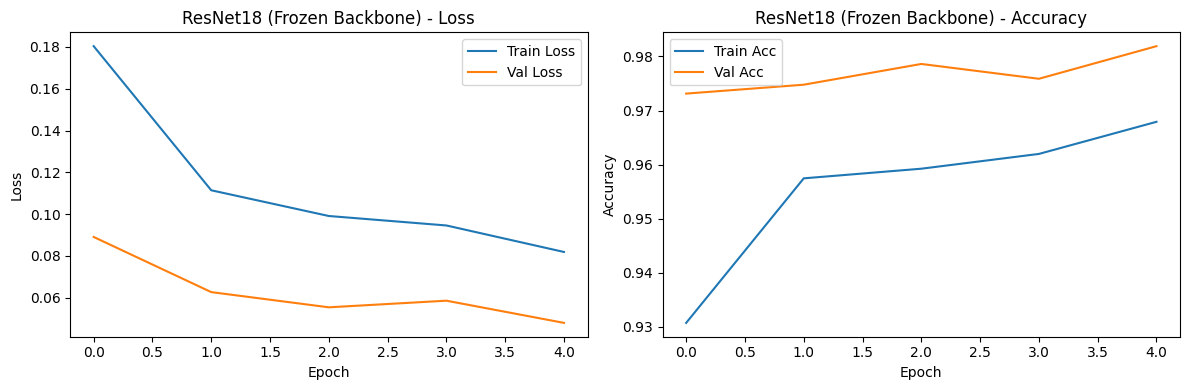

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_resnet_fc["train_loss"], label="Train Loss")
plt.plot(history_resnet_fc["val_loss"], label="Val Loss")
plt.title("ResNet18 (Frozen Backbone) - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet_fc["train_acc"], label="Train Acc")
plt.plot(history_resnet_fc["val_acc"], label="Val Acc")
plt.title("ResNet18 (Frozen Backbone) - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 🚀 Optional Advanced Blocks

The baseline ResNet18 is already strong.

But in real projects, we often improve training using:

1. Dynamic Learning Rate Scheduler  
2. Early Stopping  
3. L2 Regularization  
4. L1 Regularization  
5. Fine-Tuning Deeper Layers  

---

### 🎯 Important Teaching Note

These are **advanced optimization choices**, not mandatory first steps.

---

👉 We will add them as optional blocks

# ⚙️ Optional Advanced Block A: Dynamic Learning Rate + Early Stopping

---

### Dynamic Learning Rate

Instead of fixed learning rate:

$$
\eta = \text{constant}
$$

we adapt learning rate during training.

---

### Why?

If validation loss stops improving:

👉 reduce learning rate

This helps finer optimization.

---

### Early Stopping

Stop training when validation performance no longer improves.

---

### Why?

- Avoid overfitting
- Save training time
- Keep best model

In [ ]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
def train_model_advanced(
    model, train_loader, val_loader, criterion, optimizer, device,
    num_epochs=10, scheduler=None, early_stopping=None, l1_lambda=0.0
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0.0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)

            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
                loss = loss + l1_lambda * l1_penalty

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

        train_loss = running_loss / len(train_loader)
        train_acc = running_acc / len(train_loader)

        model.eval()
        val_running_loss = 0.0
        val_running_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                val_running_acc += calculate_accuracy(outputs, labels)

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_running_acc / len(val_loader)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

        if early_stopping is not None:
            early_stopping(val_loss)
            if early_stopping.early_stop:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
resnet18_sched = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18_sched.fc.in_features
resnet18_sched.fc = nn.Linear(num_features, 2)

for param in resnet18_sched.parameters():
    param.requires_grad = False
for param in resnet18_sched.fc.parameters():
    param.requires_grad = True

resnet18_sched = resnet18_sched.to(device)

criterion_sched = nn.CrossEntropyLoss()

optimizer_sched = optim.Adam(
    resnet18_sched.fc.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_sched,
    mode="min",
    factor=0.9,
    patience=1
)

early_stopper = EarlyStopping(patience=2, min_delta=0.0005)

In [ ]:
resnet18_sched, history_resnet_sched = train_model_advanced(
    model=resnet18_sched,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion_sched,
    optimizer=optimizer_sched,
    device=device,
    num_epochs=20,
    scheduler=scheduler,
    early_stopping=early_stopper,
    l1_lambda=0.0
)

100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:07<00:00,  3.91it/s]


Epoch [1/10] Train Loss: 0.1680, Train Acc: 0.9380, Val Loss: 0.0858, Val Acc: 0.9715, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:09<00:00,  3.76it/s]


Epoch [2/10] Train Loss: 0.1059, Train Acc: 0.9563, Val Loss: 0.0656, Val Acc: 0.9786, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [01:04<00:00,  4.08it/s]


...

Epoch [8/10] Train Loss: 0.0856, Train Acc: 0.9674, Val Loss: 0.0460, Val Acc: 0.9819, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:54<00:00,  4.83it/s]


Epoch [9/10] Train Loss: 0.0840, Train Acc: 0.9658, Val Loss: 0.0421, Val Acc: 0.9825, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:57<00:00,  4.57it/s]


Epoch [10/10] Train Loss: 0.0802, Train Acc: 0.9688, Val Loss: 0.0447, Val Acc: 0.9830, LR: 0.001000


# 🧲 Optional Advanced Block B: L2 Regularization

L2 regularization penalizes large weights:

$$
\mathcal{L}_{total} = \mathcal{L}_{CE} + \lambda \sum_i w_i^2
$$

---

### 🎯 Why?

- discourages very large weights
- improves generalization
- widely used in practice

---

### In PyTorch

L2 regularization is commonly added using:

`weight_decay`

In [ ]:
resnet18_l2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18_l2.fc.in_features
resnet18_l2.fc = nn.Linear(num_features, 2)

for param in resnet18_l2.parameters():
    param.requires_grad = False
for param in resnet18_l2.fc.parameters():
    param.requires_grad = True

resnet18_l2 = resnet18_l2.to(device)

criterion_l2 = nn.CrossEntropyLoss()

optimizer_l2 = optim.Adam(
    resnet18_l2.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
resnet18_l2, history_resnet_l2 = train_model_advanced(
    model=resnet18_l2,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion_l2,
    optimizer=optimizer_l2,
    device=device,
    num_epochs=5
)

100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:53<00:00,  4.89it/s]


Epoch [1/5] Train Loss: 0.1655, Train Acc: 0.9390, Val Loss: 0.0733, Val Acc: 0.9742, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:54<00:00,  4.83it/s]


Epoch [2/5] Train Loss: 0.1100, Train Acc: 0.9562, Val Loss: 0.0597, Val Acc: 0.9819, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:55<00:00,  4.71it/s]


Epoch [3/5] Train Loss: 0.0966, Train Acc: 0.9641, Val Loss: 0.0551, Val Acc: 0.9797, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:56<00:00,  4.67it/s]


Epoch [4/5] Train Loss: 0.0948, Train Acc: 0.9620, Val Loss: 0.0514, Val Acc: 0.9825, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:59<00:00,  4.39it/s]


Epoch [5/5] Train Loss: 0.0805, Train Acc: 0.9679, Val Loss: 0.0487, Val Acc: 0.9819, LR: 0.001000


# ✂️ Optional Advanced Block C: L1 Regularization

L1 regularization penalizes absolute weight magnitude:

$$
\mathcal{L}_{total} = \mathcal{L}_{CE} + \lambda \sum_i |w_i|
$$

---

### 🎯 Why?

- can encourage sparsity
- useful for compact representations

---

### ⚠️ Practical Note

L1 is usually added manually to the loss function.

In [ ]:
resnet18_l1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18_l1.fc.in_features
resnet18_l1.fc = nn.Linear(num_features, 2)

for param in resnet18_l1.parameters():
    param.requires_grad = False
for param in resnet18_l1.fc.parameters():
    param.requires_grad = True

resnet18_l1 = resnet18_l1.to(device)

criterion_l1 = nn.CrossEntropyLoss()
optimizer_l1 = optim.Adam(resnet18_l1.fc.parameters(), lr=0.001)

In [ ]:
resnet18_l1, history_resnet_l1 = train_model_advanced(
    model=resnet18_l1,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion_l1,
    optimizer=optimizer_l1,
    device=device,
    num_epochs=5,
    l1_lambda=1e-5
)

100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:51<00:00,  5.09it/s]


Epoch [1/5] Train Loss: 0.1770, Train Acc: 0.9329, Val Loss: 0.0798, Val Acc: 0.9715, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:54<00:00,  4.84it/s]


Epoch [2/5] Train Loss: 0.1071, Train Acc: 0.9573, Val Loss: 0.0583, Val Acc: 0.9808, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:53<00:00,  4.89it/s]


Epoch [3/5] Train Loss: 0.0924, Train Acc: 0.9647, Val Loss: 0.0636, Val Acc: 0.9759, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:55<00:00,  4.71it/s]


Epoch [4/5] Train Loss: 0.0876, Train Acc: 0.9647, Val Loss: 0.0496, Val Acc: 0.9819, LR: 0.001000


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:56<00:00,  4.69it/s]


Epoch [5/5] Train Loss: 0.0915, Train Acc: 0.9646, Val Loss: 0.0511, Val Acc: 0.9808, LR: 0.001000


# 🔓 Optional Advanced Block D: Freeze vs Fine-Tune

So far, we trained only the final FC layer.

Now we compare with partial fine-tuning.

---

### Feature Extraction

$$
\theta_{\text{backbone}} = \text{fixed}
$$

Only FC is trainable.

---

### Partial Fine-Tuning

Unfreeze deeper layers such as:

- `layer4`
- `fc`

---

### 🎯 Why?

Later layers are more task-specific.

So adapting them may improve performance on cat-vs-dog classification.

In [ ]:
resnet18_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = resnet18_ft.fc.in_features
resnet18_ft.fc = nn.Linear(num_features, 2)

for param in resnet18_ft.parameters():
    param.requires_grad = False

# Unfreeze layer4 and fc
for param in resnet18_ft.layer4.parameters():
    param.requires_grad = True

for param in resnet18_ft.fc.parameters():
    param.requires_grad = True

resnet18_ft = resnet18_ft.to(device)

trainable_params_ft = sum(p.numel() for p in resnet18_ft.parameters() if p.requires_grad)
print("Trainable parameters after partial fine-tuning:", trainable_params_ft)

Trainable parameters after partial fine-tuning: 8394754


In [ ]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, resnet18_ft.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="min",
    factor=0.8,
    patience=1
)

early_stopper_ft = EarlyStopping(patience=3, min_delta=0.0005)

In [ ]:
resnet18_ft, history_resnet_ft = train_model_advanced(
    model=resnet18_ft,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion_ft,
    optimizer=optimizer_ft,
    device=device,
    num_epochs=15,
    scheduler=scheduler_ft,
    early_stopping=early_stopper_ft,
    l1_lambda=0.0
)

100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:54<00:00,  4.78it/s]


Epoch [1/15] Train Loss: 0.0934, Train Acc: 0.9622, Val Loss: 0.0415, Val Acc: 0.9868, LR: 0.000100


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:52<00:00,  5.01it/s]


Epoch [2/15] Train Loss: 0.0430, Train Acc: 0.9847, Val Loss: 0.0382, Val Acc: 0.9825, LR: 0.000100


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:51<00:00,  5.10it/s]


...

Epoch [6/15] Train Loss: 0.0094, Train Acc: 0.9966, Val Loss: 0.0415, Val Acc: 0.9836, LR: 0.000050


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:50<00:00,  5.21it/s]


Epoch [7/15] Train Loss: 0.0107, Train Acc: 0.9967, Val Loss: 0.0437, Val Acc: 0.9874, LR: 0.000025


100%|████████████████████████████████████████████████████████████████████████████████| 263/263 [00:53<00:00,  4.92it/s]


Epoch [8/15] Train Loss: 0.0066, Train Acc: 0.9981, Val Loss: 0.0424, Val Acc: 0.9863, LR: 0.000025
Early stopping triggered.


# 🧠 Freeze vs Fine-Tune: What Should We Expect?

### Feature Extraction
- faster
- fewer trainable parameters
- lower overfitting risk

---

### Partial Fine-Tuning
- more adaptation to target task
- potentially better accuracy
- higher compute cost
- higher overfitting risk

---

### 🎯 Key Insight

There is no universally best option.

Choice depends on:

- data size
- similarity to pretraining domain
- compute budget
- risk of overfitting

# ✅ Concept Check

### Q1. Why do we use ImageNet normalization for ResNet18?

**Answer:**
Because pretrained ResNet18 was trained on ImageNet, so matching preprocessing helps transfer learning work properly.

---

### Q2. Why is augmentation applied only to training data?

**Answer:**
Because training data should be diversified, while validation/test should remain stable for fair evaluation.

---

### Q3. What does freezing layers mean?

**Answer:**
Their weights are kept fixed and are not updated during backpropagation.

---

### Q4. What is the role of a learning rate scheduler?

**Answer:**
It adjusts the learning rate during training to improve convergence.

---

### Q5. What does early stopping do?

**Answer:**
It stops training when validation performance stops improving, helping avoid overfitting.

---

### Q6. How is L2 regularization added in PyTorch?

**Answer:**
Using `weight_decay` in the optimizer.

---

### Q7. Why might fine-tuning `layer4` help?

**Answer:**
Because deeper layers are more task-specific and can adapt better to the cat-vs-dog problem.